# **Project Overview: Solar Image Data Analysis**
This project **automates the retrieval and processing** of solar imagery. It uses **sunpy** and **astropy** to search for specific **wavelengths** (representing different temperatures of the solar atmosphere) and **magnetic field data**, then prepares these maps for **scientific visualization**.

### **1. Library Setup and Configuration**
The first step is **importing the necessary tools**. We use **numpy** for calculations, **matplotlib** for plotting, and **sunpy/astropy** for astronomical data handling.

In [1]:
# ---------------------------
# Standard libraries
# ---------------------------
import numpy as np
import pandas as pd

# ---------------------------
# Astropy / Coordinates / Units
# ---------------------------
import astropy.units as u
from astropy.coordinates import SkyCoord

# ---------------------------
# SunPy (maps, solar constants, and data access)
# ---------------------------
import sunpy.map
from sunpy.sun import constants as sun_const
from sunpy.net import Fido
from sunpy.net import attrs as a

# ---------------------------
# Image processing
# ---------------------------
from skimage.measure import label, regionprops
from scipy.ndimage import gaussian_filter
from aiapy.calibrate import register

# ---------------------------
# Plotting and visualization
# ---------------------------
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ---------------------------
# Enable interactive plotting
# ---------------------------
plt.ion()

### **2. Searching for Solar Data**
We use **Fido.search** to look for specific datasets.

* **AIA Data:** Captures the **solar corona** (193 Å wavelength).
* **HMI Data:** Captures the **Line-of-Sight (LOS)** magnetic field.

---

### **Key Concepts for Understanding the Code**

|** Feature **|** Description** |
| :--- | :--- |
| **Fido** | The primary interface in **sunpy** to search for and download solar data from various archives. |
| **Wavelength (193 Å)** | This specific **ultraviolet wavelength** is used to observe the solar corona and hot flare plasma. |
| **HMI LOS Field** | Measures the **magnetic field strength** moving toward or away from the observer. |
| **SunPy Map** | A **2D data array** coupled with a coordinate system, allowing you to plot solar features accurately. |

In [2]:
# Search for AIA data (Coronal intensity at 193 Angstroms)
# Time range: 2025-09-08
AIA_DATA = Fido.search(
    a.Time('2025-09-10 03:00:00', '2025-09-10 03:00:30'),
    a.Instrument.aia, 
    a.Wavelength(193*u.angstrom),
    a.Physobs.intensity
)

# Search for HMI data (Magnetic field measurements)
# Time range: 2015-07-07
HMI_DATA = Fido.search(
    a.Time('2025-09-10 03:00:00', '2025-09-10 03:00:59'),
    a.Instrument.hmi, 
    a.Physobs.los_magnetic_field
)

### **3. Fetching and Loading Maps**
Once the search is complete, the files are **downloaded locally** to your **Ubuntu** environment. We then convert these files into **SunPy Map objects**, which contain both the **image data** and the **metadata** (header information).

* **Local Storage:** Files are stored as **FITS (Flexible Image Transport System)** files.
* **Map Objects:** These objects are coordinate-aware, meaning they "know" where on the Sun each pixel is located.

In [3]:
# -------------------------------------------------
# Define your Ubuntu download folder (ensure it exists)
# {file} will be automatically replaced by Fido with the filename
#download_path = '/home/bhairab/Documents/project/{file}'

# -------------------------------------------------
# Fetch the data and save to the defined folder
AIA_files = Fido.fetch(AIA_DATA)#, path=download_path)


Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

aia.lev1.193A_2025_09_10T03_00_28.84Z.image_lev1.fits:   0%|          | 0.00/11.7M [00:00<?, ?B/s]

aia.lev1.193A_2025_09_10T03_00_16.84Z.image_lev1.fits:   0%|          | 0.00/11.7M [00:00<?, ?B/s]

aia.lev1.193A_2025_09_10T03_00_04.84Z.image_lev1.fits:   0%|          | 0.00/11.7M [00:00<?, ?B/s]

In [4]:
HMI_files = Fido.fetch(HMI_DATA)#, path=download_path)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

hmi.m_45s.2025.09.10_03_01_30_TAI.magnetogram.fits:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

In [5]:
AIA_files

['/home/bhairab/sunpy/data/aia.lev1.193A_2025_09_10T03_00_04.84Z.image_lev1.fits', '/home/bhairab/sunpy/data/aia.lev1.193A_2025_09_10T03_00_16.84Z.image_lev1.fits', '/home/bhairab/sunpy/data/aia.lev1.193A_2025_09_10T03_00_28.84Z.image_lev1.fits']

In [6]:
HMI_files

['/home/bhairab/sunpy/data/hmi.m_45s.2025.09.10_03_01_30_TAI.magnetogram.fits']

In [7]:
# Create SunPy Map objects from the downloaded FITS files
# aia_193: Representative of the hot solar corona
aia193 = sunpy.map.Map(AIA_files[0])

# hmi6173: Representative of the magnetic photosphere
hmi6173 = sunpy.map.Map(HMI_files[0])

### **4. Aligning Different Solar Perspectives**
In solar physics, different instruments (like **AIA** and **HMI**) have different **pixel scales**, **resolutions**, and **physical viewing properties**. Furthermore, these instruments operate on different **cadences**:

* **AIA (Atmospheric Imaging Assembly):** Captures a new image roughly every **12 seconds**, providing high-speed monitoring of the **solar corona**.
* **HMI (Helioseismic and Magnetic Imager):** Captures data roughly every **45 seconds**, focusing on the **Sun's magnetic field** and surface.

To compare them **pixel-for-pixel**—for example, to see exactly which **magnetic feature** on the surface (**HMI**) is causing a bright flare in the corona (**AIA**)—the images must be **perfectly aligned**. Because AIA images are updated nearly four times faster than HMI, we must **reproject** the high-cadence AIA data to match the **coordinate system (WCS)** of the HMI master frame.

In [8]:
# ----------------------------------------------------
# ALIGNMENT: Reprojecting AIA to match HMI coordinates
# ----------------------------------------------------
aia_reprojected = aia193.reproject_to(hmi6173.wcs)
aia_reprojected.nickname = 'AIA 193 Å (Reprojected)'

2026-04-01 07:13:19 - reproject.common - INFO: Calling _reproject_full in non-dask mode


### **5. Comparative Visualization of Aligned Solar Data**
In solar physics, we often need to see how the **magnetic "roots"** on the Sun's surface (**photosphere**) relate to the **hot plasma structures** above them (**corona**).

* **AIA (12s cadence):** Shows the **high-temperature corona**. Because it is **reprojected**, every pixel now matches the **HMI grid**.
* **HMI (45s cadence):** Shows the **magnetic field strength** ($B_{LOS}$). The **grayscale map** helps distinguish between **positive (white)** and **negative (black)** magnetic polarities.

---

### **Visualizing the Connection**
By aligning these two data sources, we can identify how **active regions** in the corona are fueled by underlying **magnetic flux**. This comparative view is essential for predicting **solar flares** and understanding the energy transfer between different layers of the solar atmosphere.

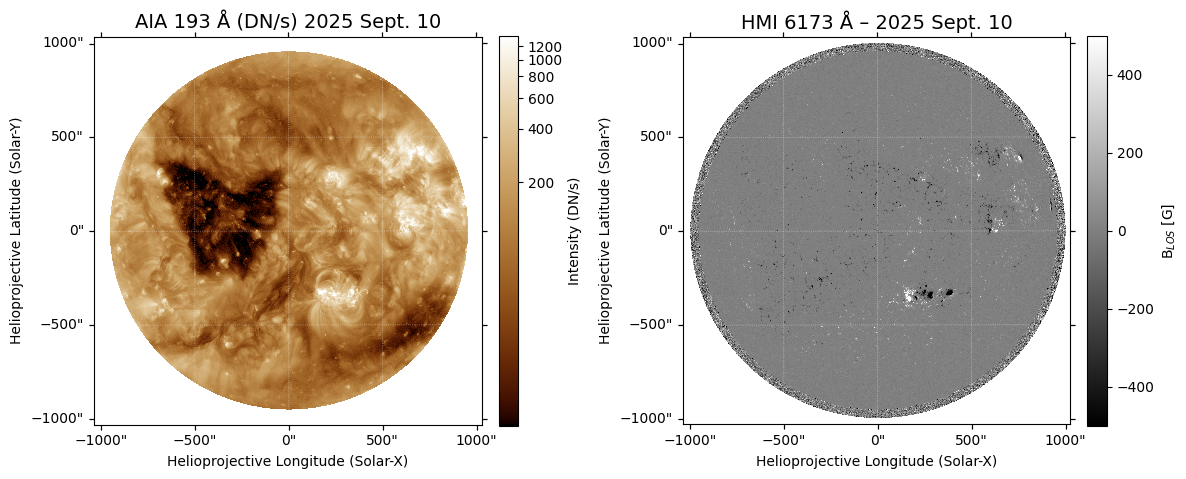

In [9]:
# ====================================================
# PROCESSING: Normalize AIA 193 Å by Exposure Time
# ====================================================
# Use exposure time from the ORIGINAL AIA map (not reprojected)
aia_exptime = aia193.exposure_time.to_value()      # seconds

# Normalize reprojected map using original exposure time
aia_norm = aia_reprojected / aia_exptime           # DN/s


# ====================================================
# FIGURE SETUP
# ====================================================
fig = plt.figure(figsize=(12, 5))


# ====================================================
# PANEL 1: AIA 193 Å (Exposure-Normalized, AIA Colormap)
# ====================================================
ax1 = fig.add_subplot(121, projection=aia_reprojected)

im1 = aia_norm.plot(
    axes=ax1,
    cmap="sdoaia193",
    clip_interval=(1, 99.9) * u.percent
)

ax1.set_title(
    "AIA 193 Å (DN/s) 2025 Sept. 10",
    fontsize=14
)

cb1 = fig.colorbar(
    im1,
    ax=ax1,
    orientation='vertical',
    fraction=0.046,
    pad=0.04
)
cb1.set_label("Intensity (DN/s)")

ax1.invert_xaxis()
ax1.invert_yaxis()


# ====================================================
# PANEL 2: HMI 6173 Å (LOS Magnetic Field, Grayscale)
# ====================================================
ax2 = fig.add_subplot(122, projection=hmi6173)

im2 = hmi6173.plot(
    axes=ax2,
    cmap="gray",
    norm=Normalize(-500, 500)
)

ax2.set_title(
    "HMI 6173 Å – 2025 Sept. 10",
    fontsize=14
)

cb2 = fig.colorbar(
    im2,
    ax=ax2,
    orientation='vertical',
    fraction=0.046,
    pad=0.04
)
cb2.set_label("B$_{LOS}$ [G]")

ax2.invert_xaxis()
ax2.invert_yaxis()


# ====================================================
# FINAL LAYOUT & EXPORT
# ====================================================
plt.tight_layout(pad=1.2)

plt.savefig(
    "/home/bhairab/Documents/project/reproject.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### **6. Region of Interest (ROI) and Advanced Visualization**
To move beyond full-disk observations, we focus on specific solar features—such as **flares** or **coronal holes**—by defining a precise **Region of Interest (ROI)** and applying advanced scaling techniques.

---

#### **Defining a Region of Interest (ROI)**
To study a specific feature, we define a "box" in space using **Helioprojective Coordinates**, which measure distances in **arcseconds (arcsec)** from the center of the Sun as seen from Earth.

* **SkyCoord:** This creates specific mathematical points in the sky based on solar metadata.
* **Bottom-left & Top-right:** These coordinates define the exact boundaries of the area we want to **"zoom in"** on.

#### **Visualizing the Selected Region**
This step plots the full Sun but overlays a **dashed box** over the selected area. This is a crucial step for scientific publications to show exactly where the data was sampled.

* **draw_quadrangle:** Automatically draws the box based on the **SkyCoord** points defined above.
* **clip_interval:** This adjusts the contrast by ignoring the brightest **0.1%** and darkest **1%** of pixels, making subtle details of the solar atmosphere more visible to the human eye.



#### **Data Normalization (DN/s)**
Raw satellite data is often recorded in **"Data Numbers" (DN)**. However, because the exposure time (how long the camera shutter is open) can vary, we must divide the pixel values by the exposure time.

* **Standardization:** This converts the image from **"total light"** to **"light per second" (DN/s)**, allowing for a fair comparison between images taken at different times or with different instruments.

#### **Final Comparison and Export**
The final block of the project creates a **high-resolution side-by-side comparison** of the **Coronal atmosphere (AIA)** and the **Magnetic surface (HMI)**.

* **Invert Axis:** Ensures the orientation matches standard **solar North/South** maps.
* **savefig:** Exports the final result as a high-quality **.png** file (**600 DPI**) suitable for a thesis or research paper.

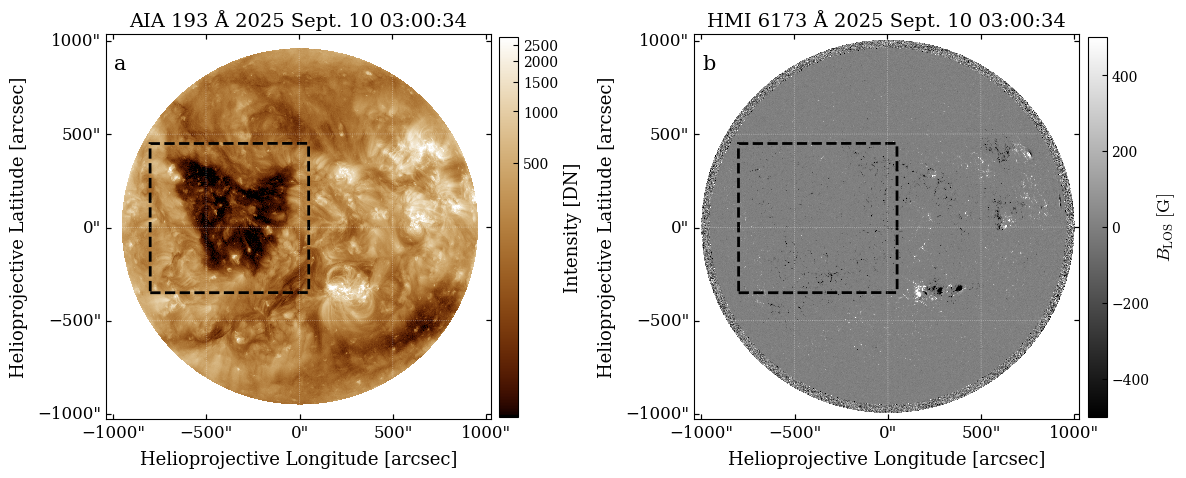

In [16]:
# -------------------------------------------------
# Define corners in the AIA coordinate frame
# -------------------------------------------------
aia_bottom_left = SkyCoord(-800 * u.arcsec, -350 * u.arcsec,
                           frame=aia_reprojected.coordinate_frame)
aia_top_right   = SkyCoord(50 * u.arcsec,  450 * u.arcsec,
                           frame=aia_reprojected.coordinate_frame)

# -------------------------------------------------
# Create figure
# -------------------------------------------------
fig = plt.figure(figsize=(12, 6))

# ===================== AIA Plot =====================
ax1 = fig.add_subplot(121, projection=aia_reprojected.wcs)
im1 = aia_reprojected.plot(
    axes=ax1,
    clip_interval=(1, 99.9) * u.percent
)

aia_reprojected.draw_quadrangle(
    bottom_left=aia_bottom_left,
    top_right=aia_top_right,
    axes=ax1,
    edgecolor="black",
    linestyle="--",
    linewidth=2
)

ax1.set_title("AIA 193 Å 2025 Sept. 10 03:00:34", fontsize=14)

ax1.coords[0].set_axislabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax1.coords[1].set_axislabel("Helioprojective Latitude [arcsec]", fontsize=13)

# Enforce uniform label rendering (Astropy-safe)
ax1.set_xlabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax1.set_ylabel("Helioprojective Latitude [arcsec]", fontsize=13)

ax1.tick_params(labelsize=12)
ax1.invert_xaxis()
ax1.invert_yaxis()

cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
cbar1.set_label("Intensity [DN]", fontsize=13)
cbar1.ax.tick_params(labelsize=10)

ax1.text(
    0.02, 0.95, "a",
    transform=ax1.transAxes,
    va="top", ha="left",
    fontsize=15
)

# ===================== HMI Plot =====================
ax2 = fig.add_subplot(122, projection=hmi6173.wcs)
im2 = hmi6173.plot(
    axes=ax2,
    cmap="grey",
    norm=Normalize(-500, 500)
)

hmi6173.draw_quadrangle(
    bottom_left=aia_bottom_left,
    top_right=aia_top_right,
    axes=ax2,
    edgecolor="black",
    linestyle="--",
    linewidth=2
)

ax2.set_title("HMI 6173 Å 2025 Sept. 10 03:00:34", fontsize=14)

ax2.coords[0].set_axislabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax2.coords[1].set_axislabel("Helioprojective Latitude [arcsec]", fontsize=13)

# Enforce uniform label rendering (Astropy-safe)
ax2.set_xlabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax2.set_ylabel("Helioprojective Latitude [arcsec]", fontsize=13)

ax2.tick_params(labelsize=12)
ax2.invert_xaxis()
ax2.invert_yaxis()

cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)
cbar2.set_label(r"$B_{\mathrm{LOS}}\ \mathrm{[G]}$", fontsize=13)
cbar2.ax.tick_params(labelsize=10)

ax2.text(
    0.02, 0.95, "b",
    transform=ax2.transAxes,
    va="top", ha="left",
    fontsize=15
)

# ----------------------------------------------------
# Layout + Save
# ----------------------------------------------------
plt.tight_layout(pad=1.2)

plt.savefig(
    "/home/bhairab/Documents/project/chbox.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### **7. Extracting and Formatting Submaps for Publication**
In this stage, we **"crop"** the large solar images to focus exclusively on the area defined by your **coordinate box**. This allows for a much higher level of detail when analyzing local solar features like **coronal holes** or **active regions**.



* **Submap Creation:** Using the **SkyCoord** boundaries defined earlier, we slice the full-disk map into a smaller, high-resolution **submap**.
* **Coordinate Preservation:** Unlike a standard image crop, a **SunPy submap** retains all the **WCS (World Coordinate System)** metadata, so your axes still show correct **arcsecond** values.
* **Publication-Ready Styling:** We apply specific **color maps** (like `sdoaia193`) and adjust the **stretch** (logarithmic or linear) to ensure that the solar features are visually distinct for research papers.

---

### **Key Benefits of Submapping:**
1.  **Reduced File Size:** Working with cropped data is computationally faster for time-series analysis.
2.  **Feature Centering:** You can track a specific **Active Region (AR)** as it rotates across the solar disk.
3.  **Enhanced Detail:** By removing the "black space" around the Sun, the **normalization** and **scaling** algorithms focus only on the relevant solar plasma.

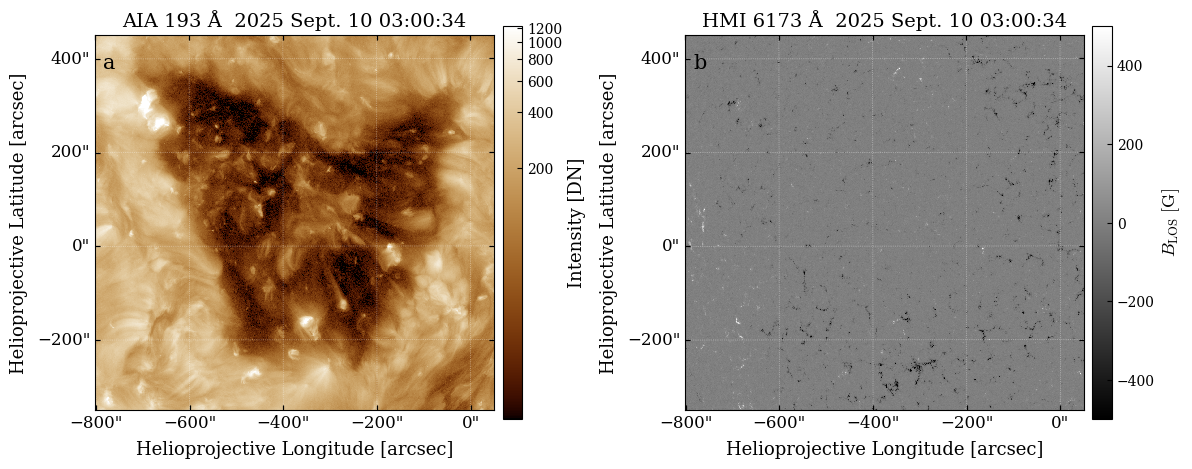

In [17]:
# -------------------------------------------------
# Global ApJ-safe style (ONE place)
# -------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# -------------------------------------------------
# Create submaps from defined region
# -------------------------------------------------
aia_sub  = aia_reprojected.submap(
    bottom_left=aia_bottom_left,
    top_right=aia_top_right
)
hmi_sub1 = hmi6173.submap(
    bottom_left=aia_bottom_left,
    top_right=aia_top_right
)

# -------------------------------------------------
# Create figure
# -------------------------------------------------
fig = plt.figure(figsize=(12, 6))

# ===================== AIA submap =====================
ax1 = fig.add_subplot(121, projection=aia_sub.wcs)
im1 = aia_sub.plot(
    axes=ax1,
    clip_interval=(1, 99.9) * u.percent
)

ax1.set_title("AIA 193 Å  2025 Sept. 10 03:00:34", fontsize=14)

ax1.coords[0].set_axislabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax1.coords[1].set_axislabel("Helioprojective Latitude [arcsec]", fontsize=13)

# Enforce uniform label rendering (Astropy-safe)
ax1.set_xlabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax1.set_ylabel("Helioprojective Latitude [arcsec]", fontsize=13)

ax1.tick_params(labelsize=12)
ax1.invert_xaxis()
ax1.invert_yaxis()

cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
cbar1.set_label("Intensity [DN]", fontsize=13)
cbar1.ax.tick_params(labelsize=10)

ax1.text(
    0.02, 0.95, "a",
    transform=ax1.transAxes,
    va="top", ha="left",
    fontsize=15
)

# ===================== HMI submap =====================
ax2 = fig.add_subplot(122, projection=hmi_sub1.wcs)
im2 = hmi_sub1.plot(
    axes=ax2,
    cmap="grey",
    norm=Normalize(-500, 500)
)

ax2.set_title("HMI 6173 Å  2025 Sept. 10 03:00:34", fontsize=14)

ax2.coords[0].set_axislabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax2.coords[1].set_axislabel("Helioprojective Latitude [arcsec]", fontsize=13)

# Enforce uniform label rendering (Astropy-safe)
ax2.set_xlabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax2.set_ylabel("Helioprojective Latitude [arcsec]", fontsize=13)

ax2.tick_params(labelsize=12)
ax2.invert_xaxis()
ax2.invert_yaxis()

cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)
cbar2.set_label(r"$B_{\mathrm{LOS}}\ \mathrm{[G]}$", fontsize=13)
cbar2.ax.tick_params(labelsize=10)

ax2.text(
    0.02, 0.95, "b",
    transform=ax2.transAxes,
    va="top", ha="left",
    fontsize=15
)

# -------------------------------------------------
# Final layout and show/save
# -------------------------------------------------
plt.tight_layout(pad=1.0)

plt.savefig(
    "/home/bhairab/Documents/project/chonly.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### **8. Feature Extraction and Boundary Mapping**
Instead of just looking at the Sun, we are now asking the computer to **"find"** a dark region (**Coronal Hole**) and draw a **boundary** around it. We then overlay this boundary on the **HMI magnetic map** to see what the magnetic field looks like specifically inside that region.

---

#### **a. Segmentation & Masking**
The code identifies **"dark" pixels** (low intensity) which usually indicate **Coronal Holes** in **AIA 193 Å** images.

* **Thresholding:** It flags any pixel with an intensity lower than **100** as "interesting."
* **Gaussian Smoothing:** It applies a slight **"blur"** to the detection. This removes **"noise"** (tiny random dots) so you get a smooth, continuous shape instead of a jagged one.
* **Labeling:** It identifies separate **"islands"** of dark pixels. The code is programmed to pick the **largest island** (the main Coronal Hole).



#### **b. Identifying the Centroid**
The code calculates the exact **center (centroid)** of the detected hole. This is useful for labeling the feature with a **marker** (in this case, "0") to track its movement over time.

#### **c. Plotting with Contours (Panel A & B)**
The most important visual tool here is `ax.contour`.

* **Outline Detection:** It takes the **"outline"** found in the AIA image and draws it as a **red line**.
* **Cross-Instrument Overlay:** Because your images are **reprojected**, the red line is drawn in the **exact same physical location** on both the **AIA plasma map** and the **HMI magnetic map**.

---

### **Scientific Insight**
By placing the **AIA contour** onto the **HMI magnetogram**, researchers can confirm if the "dark hole" corresponds to an **"open" magnetic field line**—the source of high-speed solar wind that can affect Earth's magnetosphere.

### **Important Terms to Know**

To understand the final visualization and analysis, it is helpful to define the technical parameters used to process the solar imagery.

| Term | Meaning in this Code |
| :--- | :--- |
| **Gaussian Filter** | A mathematical tool to **"smooth"** data, removing speckle noise from the detection. |
| **Sigma ($\sigma$)** | The strength of the smoothing. A **higher sigma** makes the boundary smoother but less detailed. |
| **Centroid** | The **geometric center** of the detected region, used for tracking and labeling. |
| **Contour** | The **red line** representing the **"edge"** or **"boundary"** of the solar feature. |
| **GridSpec** | A layout tool that allows **precise control** over how the two plots are positioned side-by-side. |

---

### **Visualizing the Process**

When we apply these terms, we are essentially turning a "fuzzy" satellite image into a **mathematical object**. 

* The **Gaussian Filter** ($\sigma$) ensures that we don't accidentally label a single dark pixel as a "hole." 
* The **Contour** allows us to export that shape and overlay it onto the **HMI magnetic map** to see if the magnetic field is "open" or "closed" within that specific boundary.

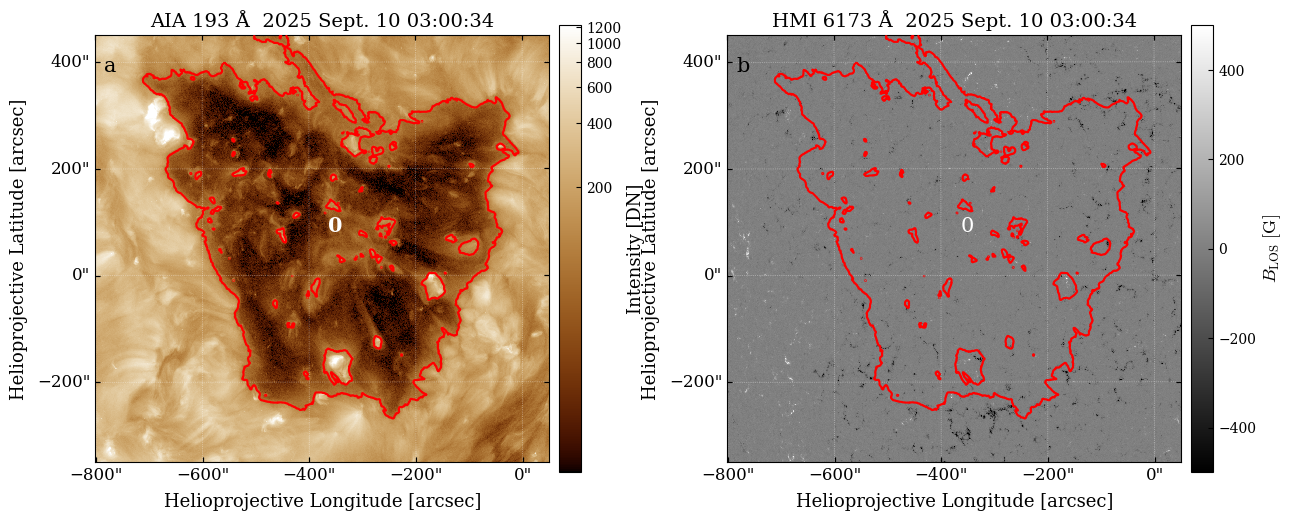

In [18]:
# Global ApJ-uniform style (SAFE) — same as above
# -------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# -------------------------------------------------
# Segment AIA dark regions + smooth
# -------------------------------------------------
threshold = 100
segmented = aia_sub.data < threshold
smoothed_mask = gaussian_filter(segmented.astype(float), sigma=2) > 0.5

# Label regions (use AIA intensity image for region finding)
labeled = label(smoothed_mask)
regions = regionprops(labeled, intensity_image=aia_sub.data)
regions = sorted(regions, key=lambda r: r.area, reverse=True)

# Safety: handle empty detection
if len(regions) == 0:
    raise ValueError("No regions found. Try adjusting threshold/sigma.")

# Keep only largest region
largest_region = regions[0]
single_mask = (labeled == largest_region.label)

# Region centroid (pixel)
cy, cx = largest_region.centroid  # (row, col)

# -------------------------------------------------
# Plot (UNIFORM with the earlier figure: GridSpec + per-axis colorbars)
# -------------------------------------------------
fig = plt.figure(figsize=(13, 6))
gs = fig.add_gridspec(1, 2)

# ===================== AIA panel =====================
ax1 = fig.add_subplot(gs[0, 0], projection=aia_sub.wcs)
im1 = aia_sub.plot(axes=ax1, clip_interval=(1, 99.9) * u.percent)
ax1.contour(single_mask, levels=[0.5], colors="red", origin="lower")

ax1.set_title("AIA 193 Å  2025 Sept. 10 03:00:34", fontsize=14)

ax1.coords[0].set_axislabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax1.coords[1].set_axislabel("Helioprojective Latitude [arcsec]", fontsize=13)
ax1.set_xlabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax1.set_ylabel("Helioprojective Latitude [arcsec]", fontsize=13)

# WCS tick labels (PDF consistency)
ax1.coords[0].set_ticklabel(size=12)
ax1.coords[1].set_ticklabel(size=12)

# label at centroid (bold like your other labels)
ax1.text(cx, cy, "0", color="white",
         ha="center", va="center", fontsize=15, fontweight="bold")

# panel label
ax1.text(0.02, 0.95, "a",
         transform=ax1.transAxes, va="top", ha="left",
         fontsize=15, color="black")

ax1.invert_xaxis()
ax1.invert_yaxis()

cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
cbar1.set_label("Intensity [DN]", fontsize=13)
cbar1.ax.tick_params(labelsize=10)

# ===================== HMI panel =====================
ax2 = fig.add_subplot(gs[0, 1], projection=hmi_sub1.wcs)
im2 = hmi_sub1.plot(axes=ax2, cmap="grey", norm=Normalize(-500, 500))
ax2.contour(single_mask, levels=[0.5], colors="red", origin="lower")

ax2.set_title("HMI 6173 Å  2025 Sept. 10 03:00:34", fontsize=14)

ax2.coords[0].set_axislabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax2.coords[1].set_axislabel("Helioprojective Latitude [arcsec]", fontsize=13)
ax2.set_xlabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax2.set_ylabel("Helioprojective Latitude [arcsec]", fontsize=13)

# WCS tick labels (PDF consistency)
ax2.coords[0].set_ticklabel(size=12)
ax2.coords[1].set_ticklabel(size=12)

# same centroid label
ax2.text(cx, cy, "0", color="white",
         ha="center", va="center", fontsize=15)

# panel label
ax2.text(0.02, 0.95, "b",
         transform=ax2.transAxes, va="top", ha="left",
         fontsize=15, color="black")

ax2.invert_xaxis()
ax2.invert_yaxis()

cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)
cbar2.set_label(r"$B_{\mathrm{LOS}}\ \mathrm{[G]}$", fontsize=13)
cbar2.ax.tick_params(labelsize=10)

# -------------------------------------------------
# IMPORTANT: no tight_layout for WCSAxes + PDF
# -------------------------------------------------

# -------------------------------------------------
# Layout + Save
# -------------------------------------------------
plt.subplots_adjust(left=0.07, right=0.93, bottom=0.10, top=0.90, wspace=0.30)

plt.savefig(
    "/home/bhairab/Documents/project/ch_boundary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

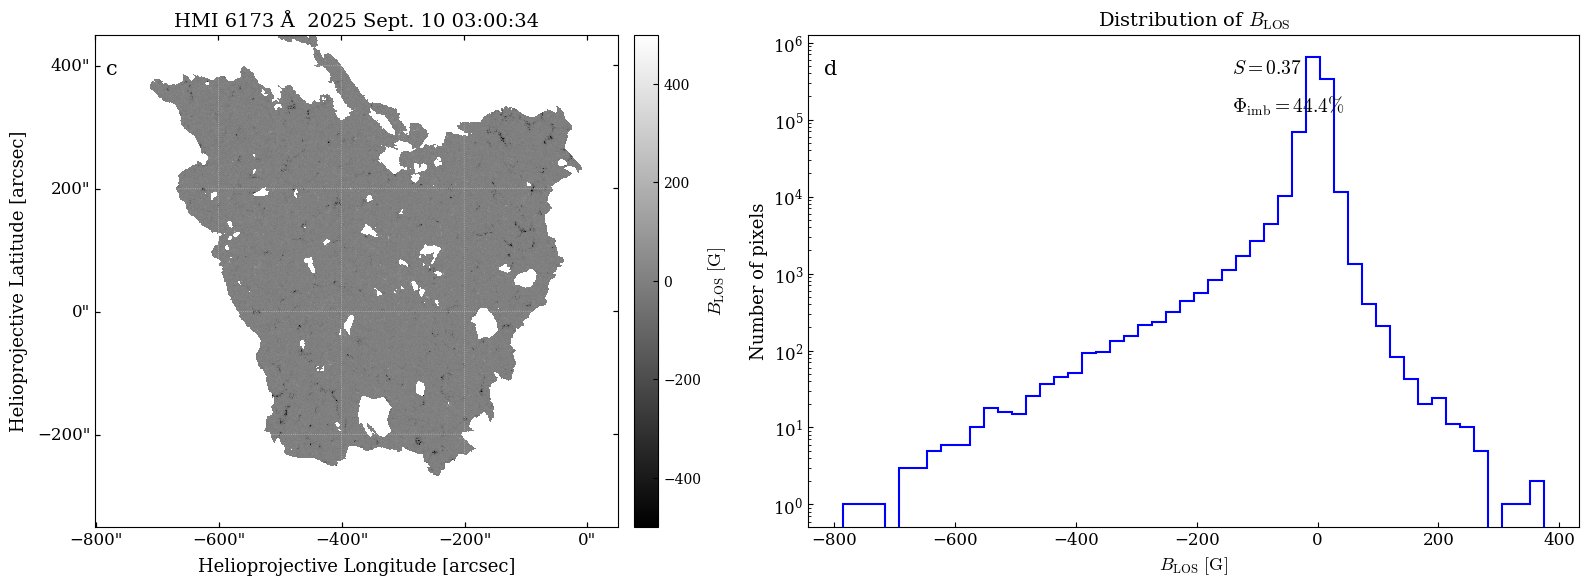

In [20]:
# Create mask from largest region
bbox = regions[0].bbox
mask = np.ones_like(hmi_sub1.data, dtype=bool)
mask[bbox[0]: bbox[2], bbox[1]: bbox[3]] = ~regions[0].image

# Create masked SunPy map
hmi_masked = sunpy.map.Map((hmi_sub1.data, hmi_sub1.meta), mask=mask)

# Extract unmasked data
unmasked_data = hmi_masked.data[~hmi_masked.mask]

# Create figure with two subplots
fig = plt.figure(figsize=(18, 6))

# ===================== Masked HMI Map =====================
ax1 = fig.add_subplot(121, projection=hmi_masked)
im = hmi_masked.plot(axes=ax1, cmap="grey", norm=Normalize(-500, 500))

ax1.set_title("HMI 6173 Å  2025 Sept. 10 03:00:34", fontsize=14)
ax1.set_xlabel("Helioprojective Longitude [arcsec]", fontsize=13)
ax1.set_ylabel("Helioprojective Latitude [arcsec]", fontsize=13)
ax1.tick_params(labelsize=12, direction="in")

ax1.invert_xaxis()
ax1.invert_yaxis()

# ✅ Colorbar EXACTLY like the AIA+HMI figure (fraction + pad only)
cbar1 = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.02)
cbar1.set_label(r"$B_{\mathrm{LOS}}\ \mathrm{[G]}$", fontsize=13)
cbar1.ax.tick_params(labelsize=10)

# Panel label
ax1.text(0.02, 0.95, "c",
         transform=ax1.transAxes,
         va="top", ha="left",
         fontsize=15)

# ===================== Histogram =====================
ax2 = fig.add_subplot(122)
ax2.hist(unmasked_data, bins=50, histtype="step", color="blue", linewidth=1.5)

ax2.set_yscale("log")
ax2.set_xlabel(r"$B_{\mathrm{LOS}}\ \mathrm{[G]}$", fontsize=13)
ax2.set_ylabel("Number of pixels", fontsize=13)
ax2.set_title(r"Distribution of $B_{\mathrm{LOS}}$", fontsize=14)
ax2.tick_params(labelsize=12, direction="in")

# Annotations
ax2.text(0.55, 0.95, r"$S = 0.37$",
         transform=ax2.transAxes,
         va="top", ha="left",
         fontsize=14)

ax2.text(0.55, 0.88, r"$\Phi_{\mathrm{imb}} = 44.4\%$",
         transform=ax2.transAxes,
         va="top", ha="left",
         fontsize=14)

# Panel label
ax2.text(0.02, 0.95, "d",
         transform=ax2.transAxes,
         va="top", ha="left",
         fontsize=15)

# Layout + Save
# ----------------------------------------------------
plt.tight_layout(pad=1.2)
plt.savefig(
    "/home/bhairab/Documents/project/Coronal_map_histogram1.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

### **9. Calculating Physical Properties and Magnetic Flux**
In this stage, we convert the pixels observed in solar images into **physical dimensions** on the Sun’s surface. Using solar constants, such as the Sun’s radius, we translate angular measurements from Earth (“arcseconds”) into physical units like **centimeters and meters**. This allows us to quantify the area of **Coronal Holes (CHs)** and calculate their **total magnetic flux**.

---

### **Step-by-Step Breakdown**

#### **a. Physical Area Calculation**
The Sun is approximately **150 million kilometers** away, so a single pixel on the camera corresponds to a large area on the solar surface. The process involves:
* **Pixel Scale:** Determining how many **arcseconds** each pixel covers.
* **Geometry Conversion:** Converting these arcseconds to radians and multiplying by the Sun’s radius ($R_{\odot}$) to find the physical length and width of a pixel in centimeters.
* **Pixel Area:** Multiplying the length and width yields the area of a single pixel in **$cm^{2}$**.



#### **b. Coronal Hole Area**
The total area of a coronal hole is calculated as the number of detected pixels ($N_{\mathrm{pixels}}$) multiplied by the area of a single pixel. The area is typically expressed in:
* **$m^{2}$**: Standard square meters.
* **$Mm^{2}$**: Megameters squared ($1\ \text{Mm} = 1,000\ \text{km}$), the standard unit in solar physics for large-scale features.

#### **c. Total Unsigned Magnetic Flux ($\Phi$ or $\Phi_{\mathrm{uns}}$)**
This step calculates the **total unsigned magnetic flux** within the CH boundary.
* **Absolute Value:** The absolute value ($|B_{\mathrm{LOS}}|$) of each magnetic pixel is taken to ensure that positive and negative magnetic fields do not cancel each other out.
* **Summation:** These absolute values are summed and multiplied by the pixel area.
* **Units:** The resulting flux is measured in **Maxwell (Mx)**, representing the total number of magnetic field lines passing through the Coronal Hole.

---

### **Mathematical Formulation**

Following the approach of **Hofmeister et al. (2017)**, the total unsigned magnetic flux is defined as:

$$\Phi = \int_{A} |B_{\mathrm{LOS}}| \, dA \approx \sum_{i} |B_{i}| \, A_{i}(\mu)$$

**Where:**
* $|B_{i}|$ is the absolute value of the **Line-of-Sight (LOS)** magnetic field in the $i$-th pixel. Taking the absolute value ensures the total magnetic "energy" is measured without cancellation between polarities.
* $A_{i}(\mu)$ is the area of the $i$-th pixel, corrected for the **heliocentric angle** $\theta$.
* $\mu = \cos \theta$ is the cosine of the angle between the observer and the solar surface (correcting for the spherical curvature of the Sun).

---

### **References**

Hofmeister, S. J., Veronig, A., Reiss, M. A., Temmer, M., Vennerstrom, S., Vršnak, B., & Heber, B. (2017). Characteristics of low-latitude coronal holes near the maximum of solar cycle 24. The Astrophysical Journal, 835(2), 268.

In [22]:
# ---- AIA: average intensity inside CH mask (DN)
aia_avg_intensity = np.mean(aia_sub.data[single_mask])

# ---- Number of pixels in CH
N_pixels = single_mask.sum()  # Only CH pixels!

# ---- Pixel scale (arcsec / pixel)
scale_x = hmi_masked.scale[0].to_value(u.arcsec / u.pixel)
scale_y = hmi_masked.scale[1].to_value(u.arcsec / u.pixel)

# ---- Constants
arcsec_to_rad = (1 * u.arcsec).to_value(u.rad)
R_sun_cm = sun_const.radius.to_value(u.cm)

# ---- Pixel area (cm^2)
pixel_area_cm2 = (scale_x * arcsec_to_rad * R_sun_cm) * \
                 (scale_y * arcsec_to_rad * R_sun_cm)

# ---- Coronal hole area
ch_area_cm2 = N_pixels * pixel_area_cm2
ch_area_m2 = ch_area_cm2 * 1e-4
ch_area_Mm2 = ch_area_cm2 * 1e-16

# ---- Total unsigned magnetic flux (Mx)
total_unsigned_flux = np.sum(
    np.abs(hmi_sub1.data[single_mask]) * pixel_area_cm2
)

# ---- Print results
print(f"Observation datetime        = {observation_datetime}")
print("====== Coronal Hole Properties ======")
print(f"Average AIA intensity        = {aia_avg_intensity:.2f} DN")
print(f"Total unsigned magnetic flux = {total_unsigned_flux:.2e} Mx")
print(f"Coronal Hole area            = {ch_area_m2:.2e} m^2")
print(f"Coronal Hole area            = {ch_area_Mm2:.2f} Mm^2")



#use it if you need to download the data in txt file
# ---- Optional: save results to file
#output_file = save_path + "CH_properties.txt"
#with open(output_file, "w") as f:
#   f.write(f"Observation datetime: {observation_datetime}\n")
#  f.write(f"Average AIA intensity: {aia_avg_intensity:.2f} DN\n")
# f.write(f"Total unsigned magnetic flux: {total_unsigned_flux:.2e} Mx\n")
# f.write(f"Coronal Hole area (m^2): {ch_area_m2:.2e}\n")
# f.write(f"Coronal Hole area (Mm^2): {ch_area_Mm2:.2f}\n")

Observation datetime        = 2025 Sept. 10 03:00:34
====== Coronal Hole Properties ======
Average AIA intensity        = 47.61 DN
Total unsigned magnetic flux = 3.58e+17 Mx
Coronal Hole area            = 3.16e+12 m^2
Coronal Hole area            = 3.16 Mm^2
